In [ ]:
import sys
import importlib

def safe_ver(mod_name, attr="__version__"):
    try:
        m = importlib.import_module(mod_name)
        return getattr(m, attr, "??")
    except Exception as e:
        return f"ERR: {e}"

print("python:", sys.version.splitlines()[0])
print("sentence-transformers:", safe_ver("sentence_transformers"))
print("transformers:", safe_ver("transformers"))
print("huggingface_hub:", safe_ver("huggingface_hub"))
print("tokenizers:", safe_ver("tokenizers"))
try:
    import google.protobuf as pb
    print("protobuf:", pb.__version__)
except Exception as e:
    print("protobuf import error:", e)


python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


2025-12-06 02:13:19.883481: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764987199.904321     159 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764987199.910693     159 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

sentence-transformers: 4.1.0
transformers: 4.53.3
huggingface_hub: 0.36.0
tokenizers: 0.21.2
protobuf: 6.33.0


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-filtered-v2-e5/data_filtered_v2.pkl
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/__huggingface_repos__.json
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/splits/test_pairs.pkl
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/splits/val_pairs.pkl
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/splits/train_pairs.pkl
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/checkpoints/model/runs/Dec05_18-02-05_78b9d5a102a8/events.out.tfevents.1764957726.78b9d5a102a8.19.0
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/checkpoints/model/eval/Information-Retrieval_evaluation_val_dataset_results.csv
/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/model_fine_tuning/intfloat-multilingual-e5-base_fine_tuning_v2/config.json
/kaggle/input/intfloat-

In [ ]:
# ----------------------------
# 1) HÀM LOAD DỮ LIỆU CẶP (query - positive)
# ----------------------------
from pathlib import Path
import pickle
from typing import List
from sentence_transformers import InputExample

def load_pairs(pkl_path: Path, preview: int = 2) -> List[InputExample]:
    """
    Đọc file .pkl chứa danh sách InputExample (mỗi mẫu gồm 2 trường: query và passage).
    - pkl_path: đường dẫn tới file .pkl chứa dữ liệu.
    - preview: số lượng mẫu đầu tiên sẽ được in ra để kiểm tra.
    Trả về: list các InputExample (định dạng chuẩn cho SentenceTransformers).
    """

    # Mở file pickle và load dữ liệu gốc (list object)
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    pairs = []     # danh sách lưu các cặp hợp lệ (query–positive)
    i = 0          # đếm số mẫu đã đọc

    for ex in data:
        # Bỏ qua nếu không phải kiểu InputExample (phòng trường hợp file lẫn object khác)
        if not isinstance(ex, InputExample):
            continue

        texts = ex.texts  # texts là list chứa các chuỗi, vd: ["query", "positive"]

        # Chỉ lấy các mẫu có đúng 2 trường (query & positive)
        if len(texts) == 2:
            q = f"{texts[0].strip()}"   # câu hỏi / truy vấn
            p = f"{texts[1].strip()}"   # đoạn văn bản trả lời tương ứng
            # Tạo một đối tượng InputExample mới (giữ nguyên format)
            pairs.append(InputExample(texts=[texts[0], texts[1]]))
        else:
            continue  # bỏ qua nếu mẫu không hợp lệ (vd. 1 hoặc 3+ trường)

        # Hiển thị trước một vài mẫu đầu để kiểm tra
        if i < preview:
            print(f"\n🔹 Mẫu {i+1}:")
            print(f"{q}")
            print(f"{p[:150]}")  # chỉ in 150 ký tự đầu của passage cho gọn

        i += 1

    # ⚠️ Lưu ý: dòng gốc của bạn có bug vì gọi 'triplets' (chưa định nghĩa)
    # → phải sửa lại thành 'pairs'
    print(f"\n✅ Tổng số mẫu hợp lệ: {len(pairs)}")

    return pairs
''
pairs: List[InputExample] = load_pairs('/kaggle/input/data-filtered-v2-e5/data_filtered_v2.pkl')


🔹 Mẫu 1:
query: An Giang đẹp vào mùa nào?
passage: An Giang mùa nào đẹp. ở An Giang: Từ tháng 3 đến tháng 5, An Giang trong mùa nắng khô ráo. Nếu muốn ngắm thảm bèo cũng như thế giới tự nhiên 

🔹 Mẫu 2:
query: Thời gian nào là mùa nắng khô ráo ở An Giang?
passage: An Giang mùa nào đẹp. ở An Giang: Từ tháng 3 đến tháng 5, An Giang trong mùa nắng khô ráo. Nếu muốn ngắm thảm bèo cũng như thế giới tự nhiên 

✅ Tổng số mẫu hợp lệ: 65539


In [ ]:
from sklearn.model_selection import train_test_split
import pickle, os

# ----------------------------
# 2) Split train / val / test
# ----------------------------
# Giả sử `pairs` là list[InputExample] đã load ở bước trước
train_pairs, temp_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
val_pairs,  test_pairs  = train_test_split(temp_pairs, test_size=0.5, random_state=42)

print(f"Split -> Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# ----------------------------
# 3) Lưu ra 3 file .pkl
# ----------------------------
output_dir = "/kaggle/working/splits"
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, "train_pairs.pkl")
val_path   = os.path.join(output_dir, "val_pairs.pkl")
test_path  = os.path.join(output_dir, "test_pairs.pkl")

# Hàm tiện ích để lưu
def save_pkl(data, path):
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"💾 Saved {len(data)} samples → {path}")

# Lưu từng phần
save_pkl(train_pairs, train_path)
save_pkl(val_pairs, val_path)
save_pkl(test_pairs, test_path)

print("\n✅ Hoàn tất chia & lưu dữ liệu!")

Split -> Train: 52431 | Val: 6554 | Test: 6554
💾 Saved 52431 samples → /kaggle/working/splits/train_pairs.pkl
💾 Saved 6554 samples → /kaggle/working/splits/val_pairs.pkl
💾 Saved 6554 samples → /kaggle/working/splits/test_pairs.pkl

✅ Hoàn tất chia & lưu dữ liệu!


In [ ]:
train_pairs = load_pairs(train_path)
val_pairs   = load_pairs(val_path)
test_pairs  = load_pairs(test_path)

print("✅ Train pairs:", len(train_pairs))
print("✅ Val pairs:", len(val_pairs))
print("✅ Test pairs:", len(test_pairs))


🔹 Mẫu 1:
query: Khu vực lối vào cửa có những phòng chức năng nào?
passage: Khu vực lối vào cửa có phòng tiếp tân kết hợp với nhiều phòng chức năng khác. Không gian tầng trệt của Dinh Bảo Đại III. Ảnh: tiendatt120799 

🔹 Mẫu 2:
query: Có điểm tham quan nào đặc biệt ở Tả Phìn không?
passage: Tả Phìn chính là quê hương của lá thuốc tắm Dao Đỏ nổi tiếng nhiều năm nay. Vì thế đến đây du khách có cơ hội tắm lá thuốc tươi, mua đồ thổ c

✅ Tổng số mẫu hợp lệ: 52431

🔹 Mẫu 1:
query: Món ăn nào được chế biến từ trứng kiến mà tác giả thích nhất?
passage: Ẩm thực ở Bắc Giang. Lên Bắc Giang ăn đặc sản trứng kiến: Mùa này, nếu có dịp ghé thăm Bắc Giang và được chủ nhà thiết đãi những món ăn chế b

🔹 Mẫu 2:
query: Công suất phục vụ của Riyadh Metro có thể đạt bao nhiêu hành khách mỗi ngày?
passage: Điểm đến ở An Giang. Đón chờ top 4 công trình du lịch năm 2025 được mong đợi nhất: Top 4 công trình du lịch năm 2025 sau đây được thế giới mo

✅ Tổng số mẫu hợp lệ: 6554

🔹 Mẫu 1:
query: Lễ hội chùa Bà đư

In [ ]:
from __future__ import annotations

import heapq
import json
import logging
import os
from typing import TYPE_CHECKING, Callable

import numpy as np
import torch
from torch import Tensor
from tqdm import trange

from sentence_transformers.evaluation.SentenceEvaluator import SentenceEvaluator
from sentence_transformers.similarity_functions import SimilarityFunction

if TYPE_CHECKING:
    from sentence_transformers.SentenceTransformer import SentenceTransformer

logger = logging.getLogger(__name__)


class InformationRetrievalEvaluator(SentenceEvaluator):
    """
    Lớp đánh giá hiệu năng của mô hình cho bài toán Truy vấn thông tin (Information Retrieval - IR).

    Cơ chế hoạt động:
    1. Nhận vào tập câu hỏi (queries) và tập tài liệu (corpus).
    2. Mã hóa (embedding) queries và corpus thành vector.
    3. Tính độ tương đồng (similarity) giữa vector câu hỏi và vector tài liệu.
    4. Tìm ra top-k tài liệu liên quan nhất cho mỗi câu hỏi.
    5. So sánh với nhãn đúng (relevant_docs) để tính các chỉ số: MRR, NDCG, MAP, Accuracy, Precision, Recall.
    """

    def __init__(
        self,
        queries: dict[str, str],  # Dict: {query_id: nội dung query}
        corpus: dict[str, str],   # Dict: {doc_id: nội dung document}
        relevant_docs: dict[str, set[str]],  # Dict: {query_id: set các doc_id đúng/liên quan}
        corpus_chunk_size: int = 50000,      # Kích thước chunk khi xử lý corpus để tránh tràn RAM
        mrr_at_k: list[int] = [10],          # Tính Mean Reciprocal Rank tại top k
        ndcg_at_k: list[int] = [10],         # Tính Normalized Discounted Cumulative Gain tại top k
        accuracy_at_k: list[int] = [1, 3, 5, 10],      # Tỷ lệ có ít nhất 1 kết quả đúng trong top k
        precision_recall_at_k: list[int] = [1, 3, 5, 10], # Precision và Recall tại top k
        map_at_k: list[int] = [100],         # Mean Average Precision
        show_progress_bar: bool = False,
        batch_size: int = 32,
        name: str = "",
        write_csv: bool = True,              # Có ghi kết quả ra file CSV không
        truncate_dim: int | None = None,     # Cắt giảm chiều vector (nếu cần test hiệu năng chiều thấp)
        score_functions: dict[str, Callable[[Tensor, Tensor], Tensor]] | None = None, # Hàm tính điểm (Cosine, Dot product...)
        main_score_function: str | SimilarityFunction | None = None, # Hàm chính để so sánh
        query_prompt: str | None = None,     # Prompt thêm vào trước query (dùng cho các model LLM/Instruct)
        query_prompt_name: str | None = None,
        corpus_prompt: str | None = None,    # Prompt thêm vào trước document
        corpus_prompt_name: str | None = None,
        write_predictions: bool = False,     # Ghi chi tiết kết quả dự đoán ra file JSONL
    ) -> None:
        super().__init__()

        # --- BƯỚC 1: LỌC DỮ LIỆU ---
        # Chỉ giữ lại các query ID mà thực sự có đáp án trong tập relevant_docs.
        # Nếu query không có đáp án nào thì không thể đánh giá được.
        self.queries_ids = []
        for qid in queries:
            if qid in relevant_docs and len(relevant_docs[qid]) > 0:
                self.queries_ids.append(qid)

        # Tạo danh sách nội dung query tương ứng với ID đã lọc
        self.queries = [queries[qid] for qid in self.queries_ids]

        # Chuyển corpus từ dict sang list để có thể truy cập bằng index số học (cần cho việc chunking)
        self.corpus_ids = list(corpus.keys())
        self.corpus = [corpus[cid] for cid in self.corpus_ids]

        # Lưu các tham số cấu hình
        self.query_prompt = query_prompt
        self.query_prompt_name = query_prompt_name
        self.corpus_prompt = corpus_prompt
        self.corpus_prompt_name = corpus_prompt_name

        self.relevant_docs = relevant_docs
        self.corpus_chunk_size = corpus_chunk_size
        self.mrr_at_k = mrr_at_k
        self.ndcg_at_k = ndcg_at_k
        self.accuracy_at_k = accuracy_at_k
        self.precision_recall_at_k = precision_recall_at_k
        self.map_at_k = map_at_k

        self.show_progress_bar = show_progress_bar
        self.batch_size = batch_size
        self.name = name
        self.write_csv = write_csv
        self.score_functions = score_functions

        # Nếu user truyền hàm tính điểm vào thì lấy tên, không thì để trống (sẽ lấy mặc định từ model sau)
        self.score_function_names = sorted(list(self.score_functions.keys())) if score_functions else []
        self.main_score_function = SimilarityFunction(main_score_function) if main_score_function else None
        self.truncate_dim = truncate_dim

        if name:
            name = "_" + name

        # Thiết lập tên file output
        self.csv_file: str = "Information-Retrieval_evaluation" + name + "_results.csv"
        self.csv_headers = ["epoch", "steps"]

        # Tạo header cho file CSV (VD: cos_sim-Accuracy@10, dot-MRR@10...)
        self._append_csv_headers(self.score_function_names)

        self.write_predictions = write_predictions
        if self.write_predictions:
            self.predictions_file = "Information-Retrieval_evaluation" + name + "_predictions.jsonl"

    def _append_csv_headers(self, score_function_names):
        """Tạo tên cột cho file CSV ứng với từng metric và từng mức k."""
        for score_name in score_function_names:
            for k in self.accuracy_at_k:
                self.csv_headers.append(f"{score_name}-Accuracy@{k}")

            for k in self.precision_recall_at_k:
                self.csv_headers.append(f"{score_name}-Precision@{k}")
                self.csv_headers.append(f"{score_name}-Recall@{k}")

            for k in self.mrr_at_k:
                self.csv_headers.append(f"{score_name}-MRR@{k}")

            for k in self.ndcg_at_k:
                self.csv_headers.append(f"{score_name}-NDCG@{k}")

            for k in self.map_at_k:
                self.csv_headers.append(f"{score_name}-MAP@{k}")

    def __call__(
        self,
        model: SentenceTransformer,
        output_path: str | None = None,
        epoch: int = -1,
        steps: int = -1,
        *args,
        **kwargs,
    ) -> dict[str, float]:
        """
        Hàm này được gọi tự động khi chạy quá trình evaluation (VD: trong vòng lặp training).
        Nó đóng vai trò 'nhạc trưởng' điều phối quy trình đánh giá.
        """
        if epoch != -1:
            if steps == -1:
                out_txt = f" after epoch {epoch}"
            else:
                out_txt = f" in epoch {epoch} after {steps} steps"
        else:
            out_txt = ""
        if self.truncate_dim is not None:
            out_txt += f" (truncated to {self.truncate_dim})"

        logger.info(f"Information Retrieval Evaluation of the model on the {self.name} dataset{out_txt}:")

        # Nếu lúc init chưa có score function, lấy mặc định của model (thường là Cosine Similarity)
        if self.score_functions is None:
            self.score_functions = {model.similarity_fn_name: model.similarity}
            self.score_function_names = [model.similarity_fn_name]
            self._append_csv_headers(self.score_function_names)

        # --- TÍNH TOÁN METRICS (GỌI HÀM CON) ---
        scores = self.compute_metrices(model, output_path=output_path, *args, **kwargs)

        # --- GHI FILE CSV ---
        if output_path is not None and self.write_csv:
            os.makedirs(output_path, exist_ok=True)
            csv_path = os.path.join(output_path, self.csv_file)

            # Nếu file chưa tồn tại, ghi header trước
            if not os.path.isfile(csv_path):
                fOut = open(csv_path, mode="w", encoding="utf-8")
                fOut.write(",".join(self.csv_headers))
                fOut.write("\n")
            else:
                fOut = open(csv_path, mode="a", encoding="utf-8")

            # Ghi dữ liệu dòng hiện tại
            output_data = [epoch, steps]
            for name in self.score_function_names:
                for k in self.accuracy_at_k:
                    output_data.append(scores[name]["accuracy@k"][k])

                for k in self.precision_recall_at_k:
                    output_data.append(scores[name]["precision@k"][k])
                    output_data.append(scores[name]["recall@k"][k])

                for k in self.mrr_at_k:
                    output_data.append(scores[name]["mrr@k"][k])

                for k in self.ndcg_at_k:
                    output_data.append(scores[name]["ndcg@k"][k])

                for k in self.map_at_k:
                    output_data.append(scores[name]["map@k"][k])

            fOut.write(",".join(map(str, output_data)))
            fOut.write("\n")
            fOut.close()

        # --- XÁC ĐỊNH PRIMARY METRIC ---
        # Dùng để quyết định xem model checkpoint này có phải là tốt nhất không.
        # Mặc định ưu tiên NDCG cao nhất.
        if not self.primary_metric:
            if self.main_score_function is None:
                score_function = max(
                    [(name, scores[name]["ndcg@k"][max(self.ndcg_at_k)]) for name in self.score_function_names],
                    key=lambda x: x[1],
                )[0]
                self.primary_metric = f"{score_function}_ndcg@{max(self.ndcg_at_k)}"
            else:
                self.primary_metric = f"{self.main_score_function.value}_ndcg@{max(self.ndcg_at_k)}"

        # Làm phẳng dict kết quả để trả về (thuận tiện cho việc logging của Trainer)
        metrics = {
            f"{score_function}_{metric_name.replace('@k', '@' + str(k))}": value
            for score_function, values_dict in scores.items()
            for metric_name, values in values_dict.items()
            for k, value in values.items()
        }
        metrics = self.prefix_name_to_metrics(metrics, self.name)
        self.store_metrics_in_model_card_data(model, metrics, epoch, steps)
        return metrics

    def compute_metrices(
        self,
        model: SentenceTransformer,
        corpus_model=None,
        corpus_embeddings: Tensor | None = None,
        output_path: str | None = None,
    ) -> dict[str, float]:
        """
        Đây là trái tim của thuật toán đánh giá.
        Quy trình:
        1. Encode Query.
        2. Encode Corpus (theo từng chunk nhỏ).
        3. Tính điểm similarity giữa Query và Chunk.
        4. Dùng Heap để duy trì danh sách Top-K văn bản tốt nhất (giúp tiết kiệm bộ nhớ).
        """
        if corpus_model is None:
            corpus_model = model

        # Xác định k lớn nhất cần tìm (để giới hạn kích thước heap)
        max_k = max(
            max(self.mrr_at_k),
            max(self.ndcg_at_k),
            max(self.accuracy_at_k),
            max(self.precision_recall_at_k),
            max(self.map_at_k),
        )

        # 1. Encode toàn bộ queries
        query_embeddings = self.embed_inputs(
            model,
            self.queries,
            encode_fn_name="query",
            prompt_name=self.query_prompt_name,
            prompt=self.query_prompt,
        )

        # Khởi tạo list chứa kết quả cho từng score function.
        # queries_result_list[name][i] sẽ là một Heap chứa top-k kết quả cho query thứ i
        queries_result_list = {}
        for name in self.score_functions:
            queries_result_list[name] = [[] for _ in range(len(query_embeddings))]

        # 2. Xử lý Corpus theo từng Chunk (để không bị Out of Memory với corpus lớn)
        for corpus_start_idx in trange(
            0, len(self.corpus), self.corpus_chunk_size, desc="Corpus Chunks", disable=not self.show_progress_bar
        ):
            corpus_end_idx = min(corpus_start_idx + self.corpus_chunk_size, len(self.corpus))

            # Encode chunk corpus hiện tại (nếu chưa có embeddings truyền vào sẵn)
            if corpus_embeddings is None:
                sub_corpus_embeddings = self.embed_inputs(
                    corpus_model,
                    self.corpus[corpus_start_idx:corpus_end_idx],
                    encode_fn_name="document",
                    prompt_name=self.corpus_prompt_name,
                    prompt=self.corpus_prompt,
                )
            else:
                sub_corpus_embeddings = corpus_embeddings[corpus_start_idx:corpus_end_idx]

            # 3. Tính điểm Similarity và cập nhật Heap
            for name, score_function in self.score_functions.items():
                # Tính ma trận similarity: [num_queries x corpus_chunk_size]
                pair_scores = score_function(query_embeddings, sub_corpus_embeddings)

                # Lấy Top-k trong chunk hiện tại bằng torch (rất nhanh trên GPU)
                pair_scores_top_k_values, pair_scores_top_k_idx = torch.topk(
                    pair_scores, min(max_k, len(pair_scores[0])), dim=1, largest=True, sorted=False
                )
                pair_scores_top_k_values = pair_scores_top_k_values.cpu().tolist()
                pair_scores_top_k_idx = pair_scores_top_k_idx.cpu().tolist()

                # Cập nhật Global Heap cho từng query
                for query_itr in range(len(query_embeddings)):
                    for sub_corpus_id, score in zip(
                        pair_scores_top_k_idx[query_itr], pair_scores_top_k_values[query_itr]
                    ):
                        # Quy đổi từ index trong chunk về index toàn cục của corpus
                        corpus_id = self.corpus_ids[corpus_start_idx + sub_corpus_id]

                        # Logic Heap:
                        # - Nếu chưa đủ max_k phần tử: cứ thêm vào.
                        # - Nếu đã đủ: đẩy phần tử mới vào và loại bỏ phần tử bé nhất (heappushpop).
                        # Lưu ý: heapq trong Python là min-heap, nên nó sẽ loại phần tử có score thấp nhất, giữ lại các score cao.
                        if len(queries_result_list[name][query_itr]) < max_k:
                            heapq.heappush(queries_result_list[name][query_itr], (score, corpus_id))
                        else:
                            heapq.heappushpop(queries_result_list[name][query_itr], (score, corpus_id))

        # Chuyển đổi định dạng từ tuple (score, id) sang dict để dễ đọc ở bước sau
        for name in queries_result_list:
            for query_itr in range(len(queries_result_list[name])):
                for doc_itr in range(len(queries_result_list[name][query_itr])):
                    score, corpus_id = queries_result_list[name][query_itr][doc_itr]
                    queries_result_list[name][query_itr][doc_itr] = {"corpus_id": corpus_id, "score": score}

        # 4. Ghi file Predictions (nếu được yêu cầu)
        if self.write_predictions and output_path is not None:
            for name in queries_result_list:
                base_filename = self.predictions_file.replace(".jsonl", f"_{name}.jsonl")
                json_path = os.path.join(output_path, base_filename)
                mode = "w"

                with open(json_path, mode=mode, encoding="utf-8") as fOut:
                    for query_itr in range(len(queries_result_list[name])):
                        query_id = self.queries_ids[query_itr]
                        query_text = self.queries[query_itr]
                        results = queries_result_list[name][query_itr]

                        # Heap không đảm bảo thứ tự sort, cần sort lại giảm dần trước khi ghi
                        results = sorted(results, key=lambda x: x["score"], reverse=True)

                        prediction = {
                            "query_id": query_id,
                            "query": query_text,
                            "results": results,
                        }
                        fOut.write(json.dumps(prediction) + "\n")

        logger.info(f"Queries: {len(self.queries)}")
        logger.info(f"Corpus: {len(self.corpus)}\n")

        # 5. Tính toán các chỉ số (Accuracy, MRR, NDCG...) dựa trên danh sách kết quả đã tìm được
        scores = {name: self.compute_metrics(queries_result_list[name]) for name in self.score_functions}

        # In log
        for name in self.score_function_names:
            logger.info(f"Score-Function: {name}")
            self.output_scores(scores[name])

        return scores

    # def embed_inputs(
    #     self,
    #     model: SentenceTransformer,
    #     sentences: str | list[str] | np.ndarray,
    #     encode_fn_name: str | None = None,
    #     prompt_name: str | None = None,
    #     prompt: str | None = None,
    #     **kwargs,
    # ) -> np.ndarray:
    #     """
    #     Hàm bao (wrapper) để gọi chức năng encode của model.
    #     Hỗ trợ việc chọn hàm encode (encode_query vs encode_document) cho các model bất đối xứng.
    #     """
    #     # if encode_fn_name is None:
    #     #     encode_fn = model.encode
    #     # elif encode_fn_name == "query":
    #     #     # encode_fn = model.encode_query
    #     # elif encode_fn_name == "document":
    #     #     encode_fn = model.encode_document
    #     encode_fn = model.encode
    #     return encode_fn(
    #         sentences,
    #         prompt_name=prompt_name,
    #         prompt=prompt,
    #         batch_size=self.batch_size,
    #         show_progress_bar=self.show_progress_bar,
    #         convert_to_tensor=True,  # Quan trọng: trả về Tensor để tính toán trên GPU
    #         truncate_dim=self.truncate_dim,
    #         **kwargs,
    #     )
    def embed_inputs(
            self,
            model: SentenceTransformer,
            sentences: str | list[str] | np.ndarray,
            encode_fn_name: str | None = None,
            prompt_name: str | None = None,
            prompt: str | None = None,
            **kwargs,
        ) -> np.ndarray:

            # Luôn dùng encode() vì SentenceTransformer không có encode_query/encode_document
            encode_fn = model.encode

            # Thêm prompt thủ công nếu có
            if prompt is not None:
                if isinstance(sentences, list):
                    sentences = [prompt + s for s in sentences]
                else:
                    sentences = prompt + sentences

            # Encode chuẩn, trả về numpy
            return encode_fn(
                sentences,
                batch_size=self.batch_size,
                show_progress_bar=self.show_progress_bar,
                convert_to_numpy=True,     # bắt buộc để evaluator xử lý
                **kwargs,
            )

    def compute_metrics(self, queries_result_list: list[object]):
        """
        Hàm tính toán thống kê (Math logic).
        Input: Danh sách kết quả dự đoán của model.
        Output: Dictionary các chỉ số Accuracy, Precision, Recall, MRR, NDCG, MAP.
        """
        # Khởi tạo các biến tích lũy
        num_hits_at_k = {k: 0 for k in self.accuracy_at_k}
        precisions_at_k = {k: [] for k in self.precision_recall_at_k}
        recall_at_k = {k: [] for k in self.precision_recall_at_k}
        MRR = {k: 0 for k in self.mrr_at_k}
        ndcg = {k: [] for k in self.ndcg_at_k}
        AveP_at_k = {k: [] for k in self.map_at_k}

        # Duyệt qua từng query
        for query_itr in range(len(queries_result_list)):
            query_id = self.queries_ids[query_itr]

            # Sắp xếp kết quả từ cao xuống thấp
            top_hits = sorted(queries_result_list[query_itr], key=lambda x: x["score"], reverse=True)
            query_relevant_docs = self.relevant_docs[query_id]

            # --- Accuracy@k ---
            # Chỉ cần 1 tài liệu đúng nằm trong top k là được tính 1 điểm.
            for k_val in self.accuracy_at_k:
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_hits_at_k[k_val] += 1
                        break

            # --- Precision@k & Recall@k ---
            for k_val in self.precision_recall_at_k:
                num_correct = 0
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1

                # Precision: Số câu đúng / Tổng số câu đã lấy (k)
                precisions_at_k[k_val].append(num_correct / k_val)
                # Recall: Số câu đúng tìm được / Tổng số câu đúng thực tế trong dữ liệu
                recall_at_k[k_val].append(num_correct / len(query_relevant_docs))

            # --- MRR@k (Mean Reciprocal Rank) ---
            # Quan tâm đến vị trí (rank) của kết quả đúng ĐẦU TIÊN.
            # Ví dụ: đúng ở vị trí 1 -> 1/1, vị trí 2 -> 1/2...
            for k_val in self.mrr_at_k:
                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        MRR[k_val] += 1.0 / (rank + 1)
                        break

            # --- NDCG@k (Normalized Discounted Cumulative Gain) ---
            # Quan tâm đến cả thứ tự xếp hạng của nhiều kết quả đúng.
            # Kết quả đúng ở top đầu được đánh giá cao hơn nhiều so với ở dưới.
            for k_val in self.ndcg_at_k:
                predicted_relevance = [
                    1 if top_hit["corpus_id"] in query_relevant_docs else 0 for top_hit in top_hits[0:k_val]
                ]
                true_relevances = [1] * len(query_relevant_docs)

                ndcg_value = self.compute_dcg_at_k(predicted_relevance, k_val) / self.compute_dcg_at_k(
                    true_relevances, k_val
                )
                ndcg[k_val].append(ndcg_value)

            # --- MAP@k (Mean Average Precision) ---
            # Trung bình của Precision tại mỗi lần tìm thấy một tài liệu đúng.
            # Đo lường độ ổn định của việc tìm kiếm.
            for k_val in self.map_at_k:
                num_correct = 0
                sum_precisions = 0

                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1
                        sum_precisions += num_correct / (rank + 1)

                avg_precision = sum_precisions / min(k_val, len(query_relevant_docs))
                AveP_at_k[k_val].append(avg_precision)

        # Tính trung bình (Mean) cho tất cả queries
        for k in num_hits_at_k:
            num_hits_at_k[k] /= len(self.queries)

        for k in precisions_at_k:
            precisions_at_k[k] = np.mean(precisions_at_k[k])

        for k in recall_at_k:
            recall_at_k[k] = np.mean(recall_at_k[k])

        for k in ndcg:
            ndcg[k] = np.mean(ndcg[k])

        for k in MRR:
            MRR[k] /= len(self.queries)

        for k in AveP_at_k:
            AveP_at_k[k] = np.mean(AveP_at_k[k])

        return {
            "accuracy@k": num_hits_at_k,
            "precision@k": precisions_at_k,
            "recall@k": recall_at_k,
            "ndcg@k": ndcg,
            "mrr@k": MRR,
            "map@k": AveP_at_k,
        }

    def output_scores(self, scores):
        """In log kết quả."""
        for k in scores["accuracy@k"]:
            logger.info("Accuracy@{}: {:.2f}%".format(k, scores["accuracy@k"][k] * 100))

        for k in scores["precision@k"]:
            logger.info("Precision@{}: {:.2f}%".format(k, scores["precision@k"][k] * 100))

        for k in scores["recall@k"]:
            logger.info("Recall@{}: {:.2f}%".format(k, scores["recall@k"][k] * 100))

        for k in scores["mrr@k"]:
            logger.info("MRR@{}: {:.4f}".format(k, scores["mrr@k"][k]))

        for k in scores["ndcg@k"]:
            logger.info("NDCG@{}: {:.4f}".format(k, scores["ndcg@k"][k]))

        for k in scores["map@k"]:
            logger.info("MAP@{}: {:.4f}".format(k, scores["map@k"][k]))

    @staticmethod
    def compute_dcg_at_k(relevances, k):
        """
        Tính DCG (Discounted Cumulative Gain).
        Công thức: Sum(relevance / log2(rank + 1))
        """
        dcg = 0
        for i in range(min(len(relevances), k)):
            dcg += relevances[i] / np.log2(i + 2)  # +2 vì index i chạy từ 0
        return dcg

    def get_config_dict(self):
        """Lưu cấu hình evaluator để tái sử dụng hoặc ghi log."""
        config_dict = {}
        config_dict_candidate_keys = [
            "truncate_dim",
            "query_prompt",
            "query_prompt_name",
            "corpus_prompt",
            "corpus_prompt_name",
        ]
        for key in config_dict_candidate_keys:
            if getattr(self, key) is not None:
                config_dict[key] = getattr(self, key)
        return config_dict

In [ ]:
# =====  Tạo queries / corpus / qrels =====
def ensure_prefix(s: str, kind: str) -> str:
    import re
    s = re.sub(fr"^{kind}:\s*{kind}:\s*", f"{kind}: ", s, flags=re.I)
    return s if s.lower().startswith(f"{kind}:") else f"{kind}: {s}"

def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        if len(ex.texts) != 2:
            continue
        q = ensure_prefix(ex.texts[0].strip(), "query")
        p = ensure_prefix(ex.texts[1].strip(), "passage")
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = q
        corpus[did] = p
        qrels[qid] = {did}
    return queries, corpus, qrels

queries, corpus, qrels = build_ir_inputs(test_pairs)

print(f"Queries: {len(queries)} | Corpus: {len(corpus)} | Qrels: {len(qrels)}")


Queries: 6554 | Corpus: 6554 | Qrels: 6554


In [ ]:
from sentence_transformers import SentenceTransformer

# ===== Load base model =====
BASE_MODEL_E5 = "intfloat/multilingual-e5-base"
print("\n🔹 Đang tải model base...")
model_base_e5 = SentenceTransformer(BASE_MODEL_E5)
model_base_e5 .encode_query = lambda texts, **kw: model_base_e5 .encode([f"query: {t}" for t in texts], **kw)
model_base_e5 .encode_document = lambda texts, **kw: model_base_e5 .encode([f"passage: {t}" for t in texts], **kw)

# ===== Tạo Evaluator (không ghi file) =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True

)
# ===== Chạy đánh giá (không cần output_path) =====
print("\n===== 🧭 BASE MODEL =====")
res_base_e5 = ir_eval(model_base_e5)

# In kết quả
print("=== 📊 Evaluation Results ===")
for metric, value in sorted(res_base_e5.items()):
    print(f"{metric:25s}: {value:.4f}")



🔹 Đang tải model base...


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 


===== 🧭 BASE MODEL =====


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [02:30<00:00, 150.85s/it]


=== 📊 Evaluation Results ===
cosine_accuracy@1        : 0.5549
cosine_accuracy@10       : 0.9379
cosine_accuracy@3        : 0.8375
cosine_accuracy@5        : 0.8912
cosine_map@100           : 0.7042
cosine_mrr@10            : 0.7015
cosine_ndcg@10           : 0.7601
cosine_precision@1       : 0.5549
cosine_precision@10      : 0.0938
cosine_precision@3       : 0.2792
cosine_precision@5       : 0.1782
cosine_recall@1          : 0.5549
cosine_recall@10         : 0.9379
cosine_recall@3          : 0.8375
cosine_recall@5          : 0.8912


In [ ]:
from sentence_transformers import InputExample
import re

def ensure_e5_prefix(text: str, is_query: bool) -> str:
    text = str(text).strip()

    # 0) Nếu đã đúng prefix E5 → giữ nguyên
    if is_query and text.lower().startswith("query:"):
        return text
    if not is_query and text.lower().startswith("passage:"):
        return text

    # 1) Remove mọi prefix khác nếu có
    PREFIX_PATTERN = r"^(query|question|q|search|passage|document|doc|positive|text)\s*:\s*"
    cleaned = re.sub(PREFIX_PATTERN, "", text, flags=re.IGNORECASE).strip()

    # 2) Thêm prefix chuẩn E5
    prefix = "query: " if is_query else "passage: "
    return prefix + cleaned


def build_e5_pairs_from_pairs(pairs):
    e5_pairs = []
    for ex in pairs:
        q, p = ex.texts[0], ex.texts[1]

        q = ensure_e5_prefix(q, is_query=True)
        p = ensure_e5_prefix(p, is_query=False)

        e5_pairs.append(InputExample(texts=[q, p]))
    return e5_pairs


# ---------- (C) Test ----------
train_pairs_e5 = build_e5_pairs_from_pairs(train_pairs)
print(len(train_pairs_e5))
for ex in train_pairs_e5[:3]:
    print(ex.texts)

52431
['query: Khu vực lối vào cửa có những phòng chức năng nào?', 'passage: Khu vực lối vào cửa có phòng tiếp tân kết hợp với nhiều phòng chức năng khác. Không gian tầng trệt của Dinh Bảo Đại III. Ảnh: tiendatt120799 Ở bên phải sảnh là phòng dành cho Vua Bảo Đại và thư viện, bên trái là phòng họp, phòng làm việc và phòng giải trí của nhà vua. Phòng làm việc của vua Bảo Đại được thiết kế với kiến trúc kết hợp tiểu cảnh nội và ngoại thất, mang đến cho người sinh sống bên trong cảm giác được hòa mình trọn vẹn với thiên nhiên. Ở phòng tiếp khách của vua Bảo Đại vẫn còn lưu giữ cặp sừng min của trâu rừng được chính vua Bảo Đại săn tại K’rong Pha, hai chiếc đàn piano hoàng hậu Nam Phương và các công chúa và đã từng sử dụng. Bên trong phòng làm việc của vua Bảo Đại còn có rất nhiều các hiện vật lịch sử có ý nghĩa quan trọng như ngọc tỷ hoàng đế, ấn tín quân sự, tượng của vua Khải Định và vua Bảo Đại hay quốc kỳ của các nước. Cầu thang ở Dinh III là góc check-in được nhiều người ưa thích. Ảnh

In [ ]:
# import os
# import math
# import torch
# import pickle
# import matplotlib.pyplot as plt
# from pathlib import Path
# from typing import List
# from torch.utils.data import DataLoader
# from sentence_transformers import SentenceTransformer, losses, InputExample
# from sentence_transformers.evaluation import InformationRetrievalEvaluator

# # ==========================================
# # 1. CẤU HÌNH HỆ THỐNG & HYPERPARAMETERS
# # ==========================================
# # Tắt log của W&B nếu không dùng
# os.environ["WANDB_DISABLED"] = "true"
# os.environ["WANDB_SILENT"]   = "true"

# # Đường dẫn lưu model
# OUTPUT_DIR_E5 = '/kaggle/working/model_fine_tuning/intfloat-multilingual-e5-base_fine_tuning_v2'
# os.makedirs(OUTPUT_DIR_E5, exist_ok=True)

# # Tham số huấn luyện
# BATCH_SIZE   = 8
# MAX_SEQ_LEN  = 512
# EPOCHS       = 3
# LR           = 2e-5
# WARMUP_RATIO = 0.1
# USE_AMP      = True

# # ==========================================
# # 3. CHUẨN BỊ MODEL & DATALOADER
# # ==========================================
# print(f"\n Đang tải model base: intfloat/multilingual-e5-base ...")
# model = SentenceTransformer('intfloat/multilingual-e5-base')
# model.max_seq_length = MAX_SEQ_LEN
# # Tạo DataLoader cho tập Train
# train_loader = DataLoader(
#     train_pairs,
#     batch_size = BATCH_SIZE,
#     shuffle=True,
#     drop_last=True
# )
# # ==========================================
# # 4. THIẾT LẬP EVALUATOR (CHẤM ĐIỂM)
# # ==========================================
# # Chuyển đổi Val Pairs thành Dictionary cho Evaluator
# print("\n Đang cấu hình Evaluator...")
# val_queries = {}
# val_corpus = {}
# val_relevant_docs = {}
# # Lưu ý: Evaluator cần unique ID. Ta tự sinh ID dựa trên index.
# for idx, ex in enumerate(val_pairs):
#     q_id = f"q{idx}"
#     p_id = f"p{idx}"
#     val_queries[q_id] = ex.texts[0]
#     val_corpus[p_id]  = ex.texts[1]
#     val_relevant_docs[q_id] = {p_id}
# # Khởi tạo Evaluator
# evaluator = InformationRetrievalEvaluator(
#     val_queries,
#     val_corpus,
#     val_relevant_docs,
#     name='val_dataset',
#     show_progress_bar=False,
# )

# # ==========================================
# # 5. CLASS LOSS TÙY CHỈNH (ĐỂ VẼ BIỂU ĐỒ)
# # ==========================================
# class TrackingMultipleNegativesRankingLoss(losses.MultipleNegativesRankingLoss):
#     def __init__(self, model):
#         super().__init__(model)
#         self.loss_history = []

#     def forward(self, sentence_features, labels=None):
#         loss_value = super().forward(sentence_features, labels)
#         self.loss_history.append(loss_value.item())
#         return loss_value

# train_loss = TrackingMultipleNegativesRankingLoss(model)

# # ==========================================
# # 6. HUẤN LUYỆN (TRAINING LOOP)
# # ==========================================
# steps_per_epoch = len(train_loader)
# total_steps     = steps_per_epoch * EPOCHS
# warmup_steps    = int(total_steps * WARMUP_RATIO)
# eval_steps      = math.ceil(steps_per_epoch) # Đánh giá 1 lần/epoch

# print(f"\n BẮT ĐẦU FINE-TUNING")
# print(f"   - Tổng steps: {total_steps}")
# print(f"   - Warmup steps: {warmup_steps}")
# print(f"   - Evaluation steps: {eval_steps}")
# print("-" * 50)

# model.fit(
#     train_objectives=[(train_loader, train_loss)],
#     epochs=EPOCHS,
#     optimizer_params={'lr': LR},
#     output_path=OUTPUT_DIR_E5,
#     # Cấu hình lưu Best Model
#     evaluator=evaluator,
#     evaluation_steps=eval_steps,
#     save_best_model=True,
#     use_amp=USE_AMP,
#     show_progress_bar=True
# )

# # ==========================================
# # 7. VẼ BIỂU ĐỒ LOSS (Điều chỉnh theo yêu cầu)
# # ==========================================
# def plot_loss(loss_history):
#     plt.figure(figsize=(12, 6))

#     # Tính toán đường trung bình trượt (Moving Average)
#     window = 50
#     if len(loss_history) > window:
#         ma = [sum(loss_history[i:i+window])/window for i in range(len(loss_history)-window)]

#         #  CHỈ VẼ ĐƯỜNG MOVING AVERAGE MÀU ĐỎ
#         # Loại bỏ plt.plot(loss_history, ...)
#         plt.plot(
#             range(window, len(loss_history)),
#             ma,
#             label='Loss Value (Moving Avg)', # Đổi nhãn cho rõ ràng
#             color='red',
#             linewidth=2
#         )
#     else:
#         # Trường hợp không đủ dữ liệu để tính Moving Average, vẽ Loss gốc
#         plt.plot(loss_history, label='Loss Value (Batch)', color='red', linewidth=2)


#     plt.title('Training Loss Progress', fontsize=14)
#     plt.xlabel('Training Steps')
#     plt.ylabel('Loss Value')
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

# print(f"\n Tổng số bước đã train: {len(train_loss.loss_history)}")
# plot_loss(train_loss.loss_history)

# print(f"\n QUÁ TRÌNH HOÀN TẤT!")
# print(f" Model tốt nhất đã được lưu tại: {OUTPUT_DIR_E5}")

In [ ]:
# =====  Đánh giá FINE-TUNED =====
from sentence_transformers import SentenceTransformer
print("\ Đang tải FINE-TUNED model…")
model_ft = SentenceTransformer("/kaggle/input/intfloat-multilingual-e5-base-fine-tuning-v2/transformers/default/1/model_fine_tuning/intfloat-multilingual-e5-base_fine_tuning_v2")

res_ft = ir_eval(model_ft)
print("\n===  FINE-TUNED ===")
for k in sorted(res_ft.keys()):
    print(f"{k:22s}: {res_ft[k]:.6f}")



🔹 Đang tải FINE-TUNED model…


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [02:35<00:00, 155.51s/it]



=== 📊 FINE-TUNED ===
cosine_accuracy@1     : 0.575832
cosine_accuracy@10    : 0.962923
cosine_accuracy@3     : 0.866951
cosine_accuracy@5     : 0.924168
cosine_map@100        : 0.729046
cosine_mrr@10         : 0.727271
cosine_ndcg@10        : 0.785967
cosine_precision@1    : 0.575832
cosine_precision@10   : 0.096292
cosine_precision@3    : 0.288984
cosine_precision@5    : 0.184834
cosine_recall@1       : 0.575832
cosine_recall@10      : 0.962923
cosine_recall@3       : 0.866951
cosine_recall@5       : 0.924168


In [ ]:
# ===== 6️ In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k):
        return round(res.get(prefix + k, 0.0), 4)

    print("\n So sánh kết quả (đã ghép prefix):")
    for k in keys:
        b = get(res_base, k)
        f = get(res_ft, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base_e5, res_ft, ir_eval)



📊 So sánh kết quả (đã ghép prefix):
   cosine_accuracy@1: base=0.5549 | fine=0.5758 | Δ=+0.0209 (2.09%)
   cosine_accuracy@5: base=0.8912 | fine=0.9242 | Δ=+0.0330 (3.30%)
       cosine_mrr@10: base=0.7015 | fine=0.7273 | Δ=+0.0258 (2.58%)
      cosine_ndcg@10: base=0.7601 | fine=0.7860 | Δ=+0.0259 (2.59%)
      cosine_map@100: base=0.7042 | fine=0.7290 | Δ=+0.0248 (2.48%)


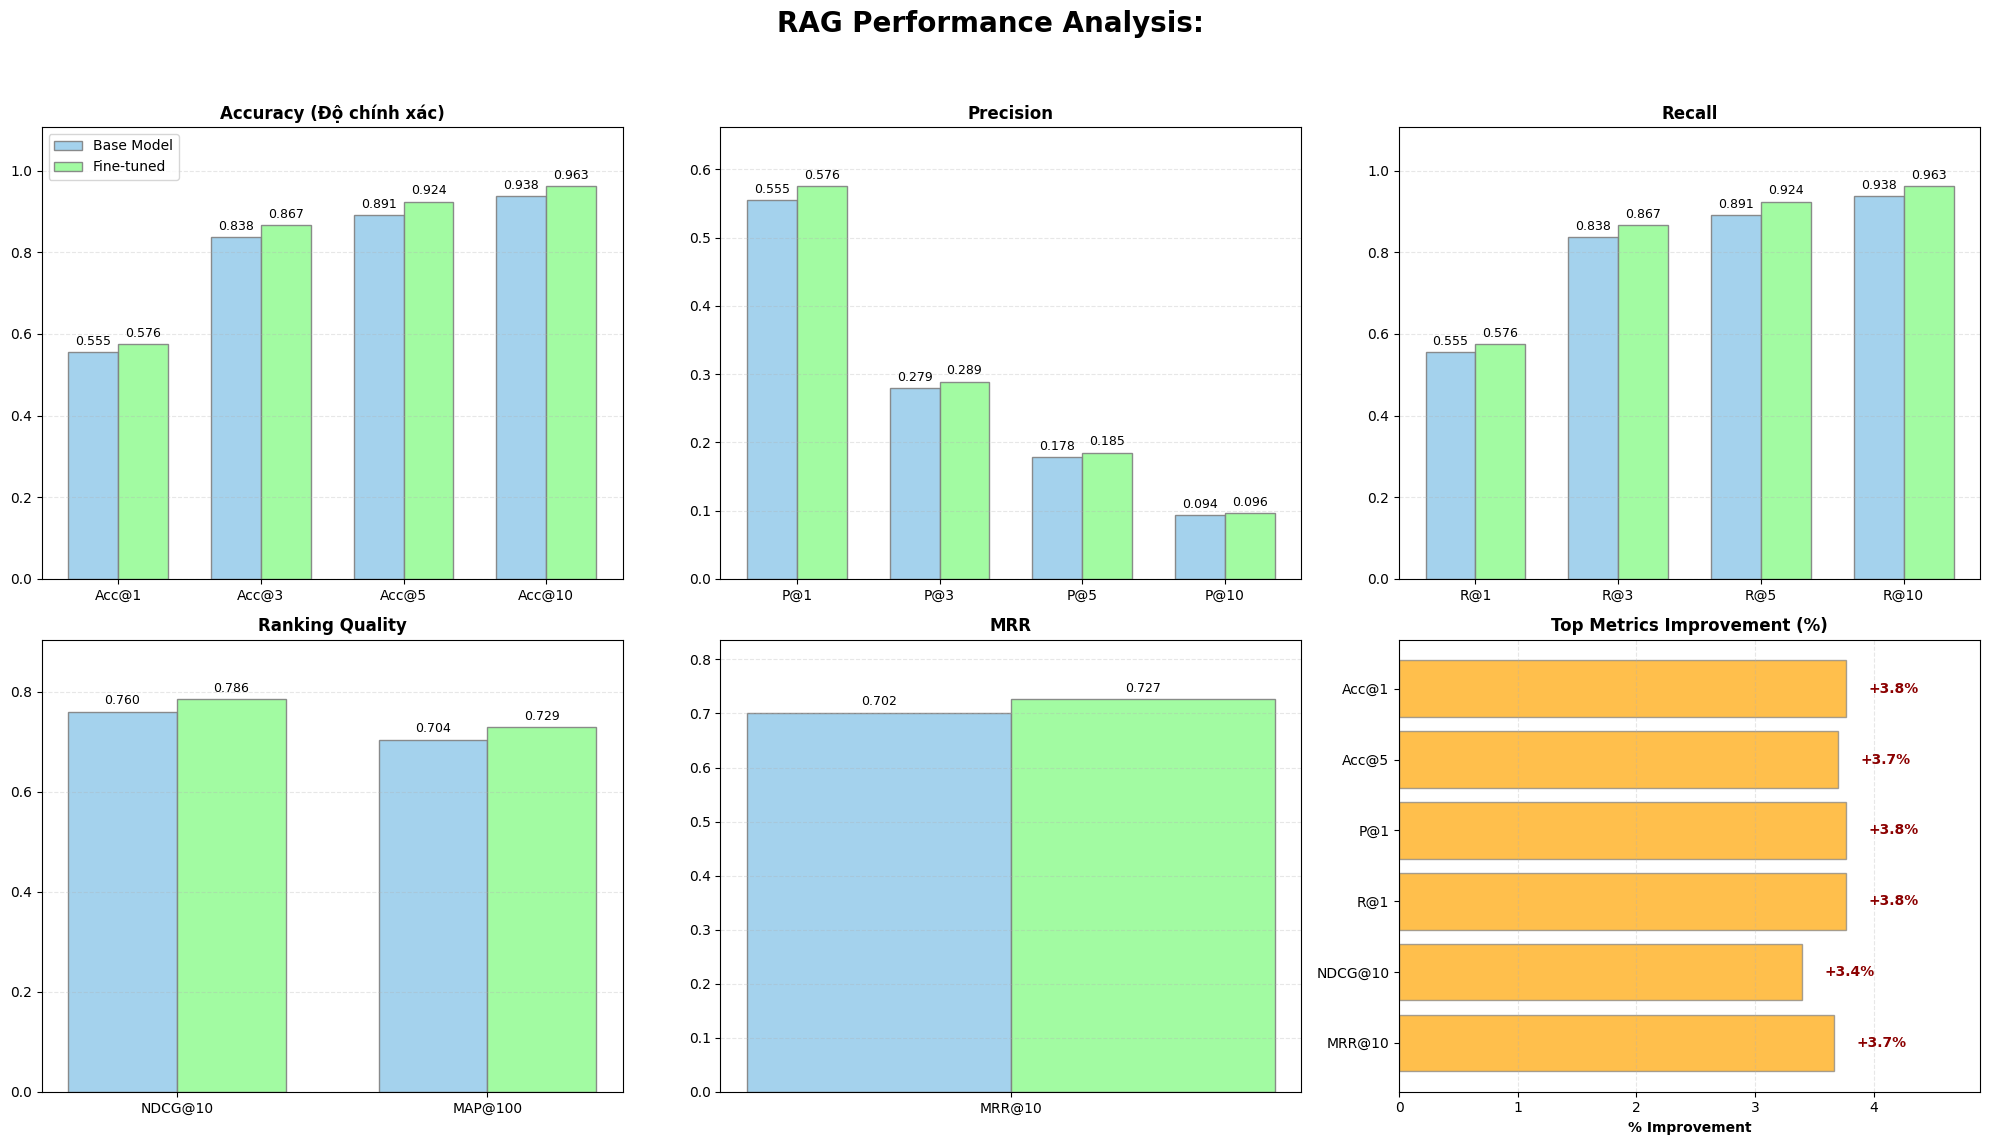

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final_v2(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Clean: Đã BỎ các chỉ số cộng thêm (+0.xx) màu xanh/đỏ.
    Chỉ hiển thị giá trị thực tế của từng cột.
    """

    # Kiểm tra dữ liệu
    if not res_base or not res_ft:
        print(" LỖI: Dữ liệu đầu vào bị rỗng!")
        return

    # 1. Xử lý Prefix key
    prefix = f"{evaluator_name}_" if evaluator_name else ""
    test_key = f"{prefix}cosine_accuracy@1"
    if test_key not in res_base:
        prefix = ""

    # Định nghĩa dữ liệu
    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Precision": [
            ("P@1", f"{prefix}cosine_precision@1"),
            ("P@3", f"{prefix}cosine_precision@3"),
            ("P@5", f"{prefix}cosine_precision@5"),
            ("P@10", f"{prefix}cosine_precision@10")
        ],
        "Recall": [
            ("R@1", f"{prefix}cosine_recall@1"),
            ("R@3", f"{prefix}cosine_recall@3"),
            ("R@5", f"{prefix}cosine_recall@5"),
            ("R@10", f"{prefix}cosine_recall@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    def get_val(res, key):
        return res.get(key, 0.0)

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    # 2. Thiết lập khung hình
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Realistic RAG Performance Comparison {evaluator_name}', fontsize=20, fontweight='bold', y=0.98)

    ax_list = axes.flatten()

    # 3. VẼ CÁC BIỂU ĐỒ CỘT (1-5)
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base Model', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)

        # Tự động chỉnh chiều cao (Giảm khoảng trống thừa vì không còn text delta)
        max_val = max(max(base_vals, default=0), max(ft_vals, default=0))
        ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1.0)

        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left', fontsize=10)

        # Hàm ghi số liệu thực tế (Màu đen)
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, rotation=0)
        autolabel(rects1)
        autolabel(rects2)

        # --- ĐÃ XÓA VÒNG LẶP GHI TEXT DELTA (+0.xx) TẠI ĐÂY ---

    # 4. BIỂU ĐỒ 6: TỔNG HỢP (SUMMARY)
    # Giữ nguyên biểu đồ này vì bản thân nó là biểu đồ tăng trưởng
    ax_summary = ax_list[5]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))

    bars = ax_summary.barh(y_pos[::-1], pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    max_pct = max([abs(p) for p in pct_changes]) if pct_changes else 10
    ax_summary.set_xlim(0, max_pct * 1.3)

    ax_summary.set_yticks(y_pos[::-1])
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement', fontweight='bold')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=12, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)

    for i, v in enumerate(pct_changes):
        text_x = v + (max_pct * 0.05) if v >= 0 else 0
        ax_summary.text(text_x, len(pct_changes)-1-i, f"{v:+.1f}%",
                        va='center', fontweight='bold', color='darkred', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final_v2(res_base_e5, res_ft)
